In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [2]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [4]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [5]:
df.duplicated().sum()
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

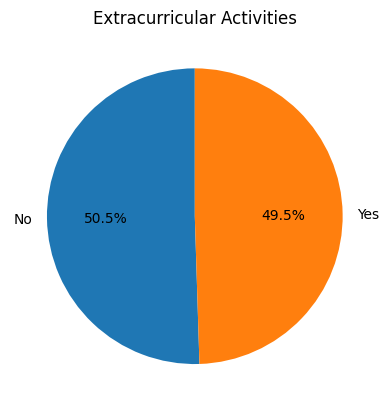

In [6]:
counts = df["Extracurricular Activities"].value_counts()
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Extracurricular Activities')
plt.show()

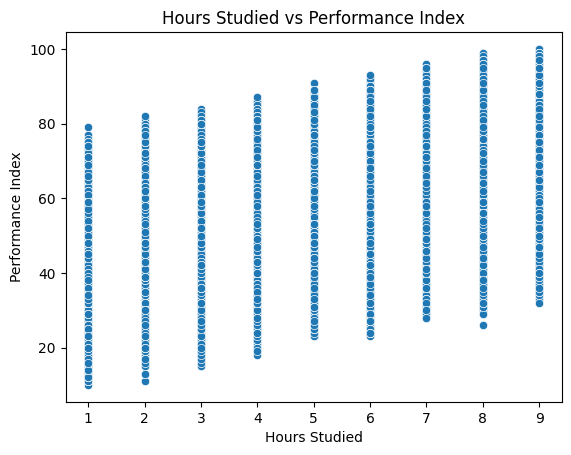

In [7]:
sns.scatterplot(
    data=df,
    x='Hours Studied',
    y='Performance Index'
)

plt.title('Hours Studied vs Performance Index')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.show()

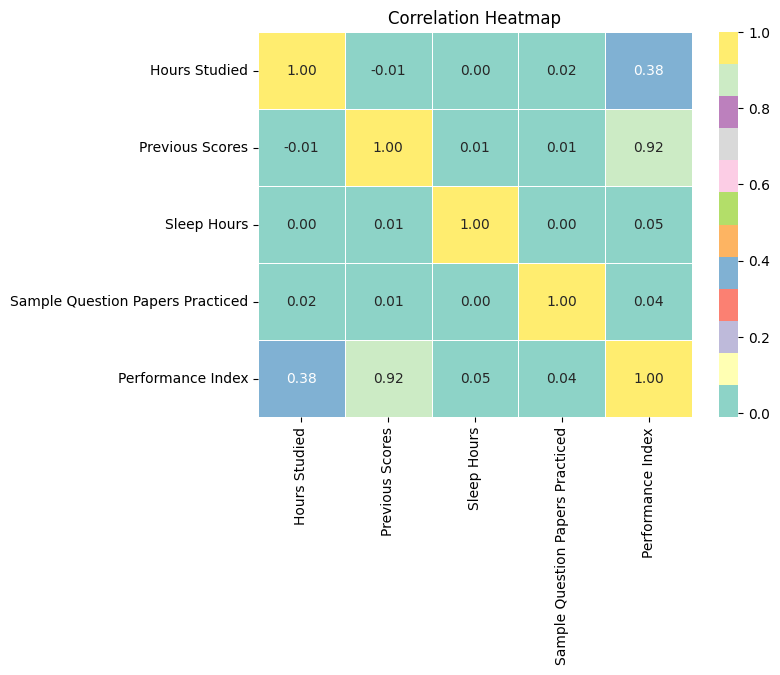

In [8]:
plt.figure(figsize=(7, 5))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Set3",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

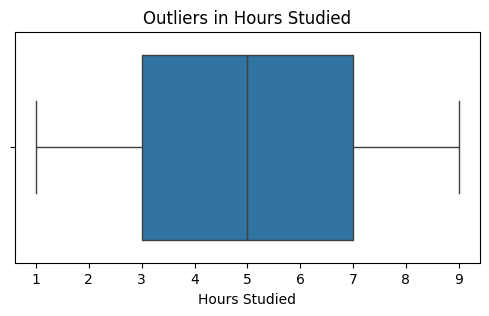

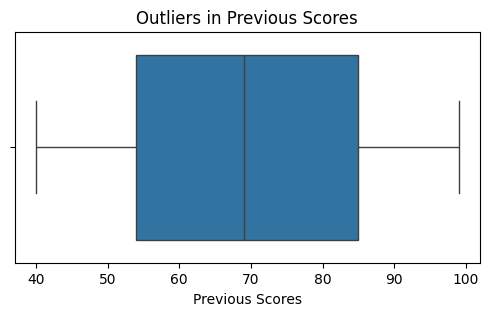

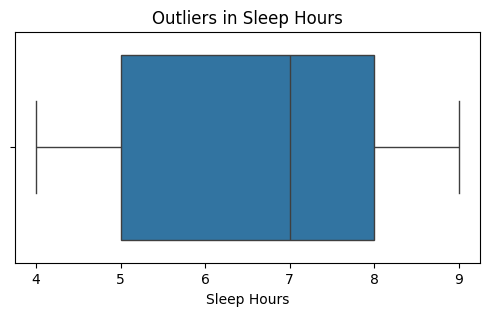

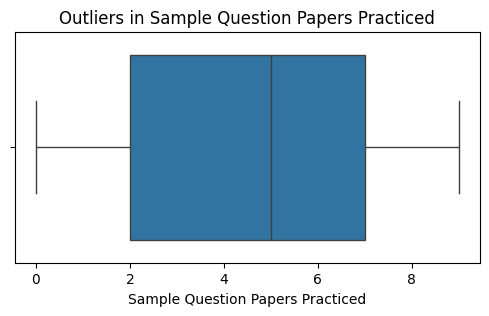

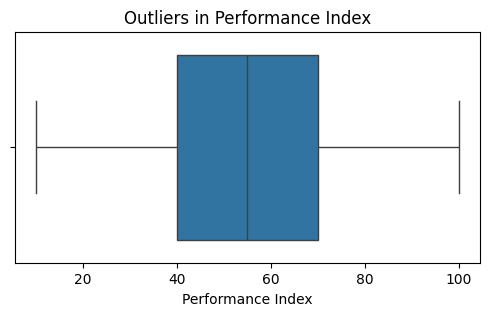

In [9]:
num_cols = df.select_dtypes(include=["int","float"]).columns
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.xlabel(col)
    plt.show()

In [10]:
print(df["Extracurricular Activities"].value_counts())
df["Extracurricular Activities"].unique()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64


array(['Yes', 'No'], dtype=object)

In [11]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].replace(["Yes","No"],[1,0])
df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_4176\3786382395.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Extracurricular Activities"] = df["Extracurricular Activities"].replace(["Yes","No"],[1,0])


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [12]:
df = df.drop(columns=["Previous Score Range"],errors="ignore")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   int64  
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 539.9 KB


In [13]:
X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]

X_remaining,X_unseen,y_remaining,y_unseen = train_test_split(X,y,test_size=0.1,random_state=35)

X_train,X_test,y_train,y_test = train_test_split(X_remaining,y_remaining,test_size=0.2,random_state=45)


In [14]:
cat_cols = ["Extracurricular Activities"]

num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols)
    ],
    verbose_feature_names_out=False
)

In [15]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
X_unseen = preprocessor.transform(X_unseen)

In [16]:
lr = LinearRegression()
lr.fit(X_train,y_train)
lrp = lr.predict(X_test)
lrpu = lr.predict(X_unseen)
print("Accuracy : ",r2_score(y_test,lrp))
print("Unseen Accuracy : ",r2_score(y_unseen,lrpu))
print("MAE : ",mean_absolute_error(y_unseen,lrpu))
print("RMSE : ",np.sqrt(mean_squared_error(y_unseen,lrpu)))

Accuracy :  0.9888099997828756
Unseen Accuracy :  0.988407933454583
MAE :  1.605692020638067
RMSE :  2.030730217501567


In [17]:
dt = DecisionTreeRegressor(random_state=45)
dt.fit(X_train,y_train)
dtp = dt.predict(X_test)
dtpu = dt.predict(X_unseen)
print("Accuracy : ",r2_score(y_test,dtp))
print("Unseen Accuracy : ",r2_score(y_unseen,dtpu))
print("MAE : ",mean_absolute_error(y_unseen,dtpu))
print("RMSE : ",np.sqrt(mean_squared_error(y_unseen,dtpu)))

Accuracy :  0.9748633310790787
Unseen Accuracy :  0.9729614724326199
MAE :  2.4412955465587043
RMSE :  3.1014395247217172


In [18]:
rf = RandomForestRegressor(n_estimators=100,max_depth=10,min_samples_split=5,random_state=45)
rf.fit(X_train,y_train)
rfp = rf.predict(X_test)
rfpu = rf.predict(X_unseen)
print("Accuracy : ",r2_score(y_test,rfp))
print("Unseen Accuracy : ",r2_score(y_unseen,rfpu))
print("MAE : ",mean_absolute_error(y_unseen,rfpu))
print("RMSE : ",np.sqrt(mean_squared_error(y_unseen,rfpu)))

Accuracy :  0.9866863460475337
Unseen Accuracy :  0.9859956960797855
MAE :  1.775956289522161
RMSE :  2.232043026036846


In [19]:
xgb = XGBRegressor()
xgb.fit(X_train,y_train)
xgbp = xgb.predict(X_test)
xgbpu = xgb.predict(X_unseen)
print("Accuracy : ",r2_score(y_test,xgbp))
print("Unseen Accuracy : ",r2_score(y_unseen,xgbpu))
print("MAE : ",mean_absolute_error(y_unseen,xgbpu))
print("RMSE : ",np.sqrt(mean_squared_error(y_unseen,xgbpu)))

Accuracy :  0.9856967771366244
Unseen Accuracy :  0.9858159955394417
MAE :  1.7678240243239924
RMSE :  2.246317952604732


In [20]:
svr = SVR(kernel="linear")
svr.fit(X_train,y_train)
svrp = svr.predict(X_test)
svrpu = svr.predict(X_unseen)
print("Accuracy : ",r2_score(y_test,svrp))
print("Unseen Accuracy : ",r2_score(y_unseen,svrpu))
print("MAE : ",mean_absolute_error(y_unseen,svrpu))
print("RMSE : ",np.sqrt(mean_squared_error(y_unseen,svrpu)))

Accuracy :  0.9888238923442613
Unseen Accuracy :  0.988409898264508
MAE :  1.6054624390037944
RMSE :  2.030558109795082


In [21]:
import pickle
with open("student_performance.pkl","wb") as file:
    pickle.dump(svr,file)
with open("preprocessor.pkl","wb") as file:
    pickle.dump(preprocessor,file)